# L12 demo: four architectures for turbofan remaining-useful-life

We predict remaining useful life (RUL) for NASA C-MAPSS FD001 engines from their sensor
history, the same dataset as L8. A sensor stream is a sequence, so we try the three
sequence architectures from the notes on the same windows: a 1D-CNN, a GRU, and a small
transformer. Each gets the same training recipe, and each is held to the same grouped
split and the same gradient-boosting baseline.

Then we ask two questions the RMSE alone does not answer. Does each model use the order of
the cycles in its window? And what does the trained transformer actually attend to?

> Data: [C-MAPSS FD001](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/),
> 100 run-to-failure engines, carried over from L8.

## Run this first on Colab

Colab starts from its own preinstalled environment rather than this course's `uv`
environment, so run the cell below before anything else. It installs what this
notebook needs and Colab does not already have. Outside Colab it does nothing, so
you can run it or skip it.


In [1]:
# Run this first on Colab. Anywhere else this cell does nothing.
#
# Only genuinely missing packages are installed, so Colab's own versions of
# everything it already ships are left alone.
#
# Generated by tools/colab_setup.py from this notebook's imports. Edit that.
import importlib.util
import subprocess
import sys

REQUIREMENTS = {
    "matplotlib": "matplotlib",
    "mlflow": "mlflow",
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "torch": "torch",
}


def _missing(module):
    try:
        return importlib.util.find_spec(module) is None
    except ModuleNotFoundError:  # the parent package is absent
        return True


if "google.colab" in sys.modules:
    need = sorted({pip for mod, pip in REQUIREMENTS.items() if _missing(mod)})
    if need:
        print("installing:", " ".join(need))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)
    print("Colab setup done." if need else "Colab: nothing to install.")


## 1. Windows, a piecewise-linear target, and a grouped split

Each engine's run becomes overlapping windows of 30 cycles across the 14 sensors that vary
in FD001 (the three settings and the other seven sensors are constant, because FD001 has
one operating condition). The target is RUL capped at 125 cycles, since health is roughly
flat early in life.

The split is by **engine**, in three parts: 20 engines are held out for scoring, and of the
80 training engines, 12 more are set aside as an inner validation set that early stopping
watches. Early stopping never sees the scoring engines. The sensors are standardized with
means and standard deviations from the training engines only.

In [2]:
import io
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

CACHE = Path('data/CMAPSS')
CACHE.mkdir(parents=True, exist_ok=True)
URL = ('https://phm-datasets.s3.amazonaws.com/NASA/'
       '6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip')
COLS = (['unit', 'cycle'] + [f'setting{i+1}' for i in range(3)]
        + [f'sensor{i+1}' for i in range(21)])
SENSORS = [f'sensor{i}' for i in (2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21)]
WINDOW, RUL_CAP, SEED = 30, 125, 0

path = CACHE / 'train_FD001.txt'
if not path.exists():
    print('downloading', URL)
    with urllib.request.urlopen(URL) as r:
        outer = zipfile.ZipFile(io.BytesIO(r.read()))
    inner_name = next(n for n in outer.namelist() if n.lower().endswith('.zip'))
    inner = zipfile.ZipFile(io.BytesIO(outer.read(inner_name)))
    for name in ['train_FD001.txt', 'test_FD001.txt', 'RUL_FD001.txt']:
        (CACHE / name).write_bytes(inner.read(name))
df = pd.read_csv(path, sep=r'\s+', header=None, names=COLS)
df = df.sort_values(['unit', 'cycle']).reset_index(drop=True)
df['rul'] = np.minimum(df.groupby('unit')['cycle'].transform('max') - df['cycle'], RUL_CAP)

# Engine-level split: 20 scoring engines, then 12 of the rest for early stopping.
engines = df['unit'].unique()
rest, test_idx = next(GroupShuffleSplit(1, test_size=20, random_state=SEED).split(engines, groups=engines))
fit_idx, val_idx = next(GroupShuffleSplit(1, test_size=12, random_state=SEED).split(rest, groups=rest))
fit_units, val_units, test_units = engines[rest[fit_idx]], engines[rest[val_idx]], engines[test_idx]

train_rows = df[df.unit.isin(np.concatenate([fit_units, val_units]))]
mu, sd = train_rows[SENSORS].mean().to_numpy(), train_rows[SENSORS].std().to_numpy()


def windows(units):
    Xs, ys, gs = [], [], []
    for unit, g in df[df.unit.isin(units)].groupby('unit'):
        arr = ((g[SENSORS].to_numpy() - mu) / sd).astype(np.float32)
        rul = g['rul'].to_numpy()
        for end in range(WINDOW, len(g) + 1):
            Xs.append(arr[end - WINDOW:end].T)
            ys.append(rul[end - 1])
            gs.append(unit)
    return np.stack(Xs), np.array(ys, np.float32), np.array(gs)


Xfit, yfit, _ = windows(fit_units)
Xval, yval, _ = windows(val_units)
Xte, yte, gte = windows(test_units)
print(f'windows: {len(Xfit)} fit, {len(Xval)} early-stopping, {len(Xte)} scoring; '
      f'each {Xfit.shape[1]} sensors x {Xfit.shape[2]} cycles')
print(f'engines: {len(fit_units)} / {len(val_units)} / {len(test_units)}, shared: '
      f'{len(set(fit_units) & set(test_units)) + len(set(val_units) & set(test_units))}')

windows: 11829 fit, 2286 early-stopping, 3616 scoring; each 14 sensors x 30 cycles
engines: 68 / 12 / 20, shared: 0


## 2. Three sequence architectures

All three read the same `(sensors, cycles)` window and differ in how cycles are allowed to
talk to each other:

- **1D-CNN**: small kernels slid along time, shared across the window, then averaged.
- **GRU**: a gated state carried cycle by cycle, read out at the last cycle.
- **Transformer**: each cycle becomes a 32-number token, every token attends to every
  other, a learned position table puts order back, and the outputs are averaged.

`TransformerNoPos` is the same transformer with the position table frozen at zero. It is
there for section 6.

In [3]:
import torch
import torch.nn as nn

torch.set_num_threads(4)


class CNN(nn.Module):
    def __init__(self, c, t, width=32, k=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(c, width, k, padding=k // 2), nn.ReLU(),
            nn.Conv1d(width, width, k, padding=k // 2), nn.ReLU(),
            nn.Conv1d(width, width, k, padding=k // 2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(width, width), nn.ReLU(), nn.Linear(width, 1))

    def forward(self, x):
        return self.net(x).squeeze(-1)


class GRU(nn.Module):
    def __init__(self, c, t, hidden=64):
        super().__init__()
        self.gru = nn.GRU(c, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.gru(x.transpose(1, 2))       # (N, T, C) in, (N, T, H) out
        return self.head(out[:, -1]).squeeze(-1)


class Transformer(nn.Module):
    def __init__(self, c, t, d=32, heads=4, layers=2):
        super().__init__()
        self.inp = nn.Linear(c, d)                  # one token per cycle
        self.pos = nn.Parameter(torch.zeros(1, t, d))
        nn.init.normal_(self.pos, std=0.02)
        layer = nn.TransformerEncoderLayer(d, heads, dim_feedforward=2 * d, dropout=0.1,
                                           batch_first=True, norm_first=True)
        self.enc = nn.TransformerEncoder(layer, layers, enable_nested_tensor=False)
        self.head = nn.Linear(d, 1)

    def forward(self, x):
        h = self.enc(self.inp(x.transpose(1, 2)) + self.pos)
        return self.head(h.mean(1)).squeeze(-1)


class TransformerNoPos(Transformer):
    def __init__(self, c, t, **kw):
        super().__init__(c, t, **kw)
        self.pos.data.zero_()
        self.pos.requires_grad_(False)


ARCHS = {'1d-cnn': CNN, 'gru': GRU, 'transformer': Transformer,
         'transformer-nopos': TransformerNoPos}
for name, cls in ARCHS.items():
    m = cls(Xfit.shape[1], WINDOW)
    print(f'{name:18s} {sum(p.numel() for p in m.parameters() if p.requires_grad):6,d} trainable parameters')

1d-cnn             13,665 trainable parameters
gru                15,425 trainable parameters
transformer        18,561 trainable parameters
transformer-nopos  17,601 trainable parameters


## 3. One training recipe, logged to MLflow

The loop is L11's, plus the four things this session explains, so the comparison is
between architectures rather than between amounts of tuning:

- a **cosine** learning-rate schedule over a 60-epoch budget,
- **early stopping** on the inner validation engines (patience 10), keeping the best epoch,
- **gradient clipping** at norm 1.0, with the norm logged so you can see whether it fires,
- **weight decay** of 1e-4 through Adam.

The target is divided by the cap, so every network regresses a number in [0, 1]. Each
architecture is one MLflow run with per-epoch train and validation RMSE, and the best
checkpoint saved as an artifact. Everything runs on CPU; the four models take a few
minutes together.

In [4]:
import math
import os
import time

os.environ.setdefault('MLFLOW_DISABLE_AGENT_HINT', '1')   # quiet a banner some versions print
import mlflow

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('cmapss-rul')

LR, WEIGHT_DECAY, CLIP, MAX_EPOCHS, PATIENCE, BATCH = 1e-3, 1e-4, 1.0, 60, 10, 256
Xfit_t, yfit_t = torch.from_numpy(Xfit), torch.from_numpy(yfit / RUL_CAP)
Xval_t, yval_t = torch.from_numpy(Xval), torch.from_numpy(yval / RUL_CAP)


@torch.no_grad()
def predict(model, X):
    model.eval()
    return RUL_CAP * model(torch.from_numpy(np.ascontiguousarray(X))).numpy()


def rmse(pred, true):
    return float(np.sqrt(np.mean((pred - true) ** 2)))


def train(name):
    torch.manual_seed(SEED)
    model = ARCHS[name](Xfit.shape[1], WINDOW)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
    lossf = nn.MSELoss()
    gen = torch.Generator().manual_seed(SEED)
    best, best_state, best_epoch, wait, t0 = math.inf, None, 0, 0, time.perf_counter()
    with mlflow.start_run(run_name=name):
        mlflow.log_params({'arch': name, 'window': WINDOW, 'rul_cap': RUL_CAP, 'lr': LR,
                           'weight_decay': WEIGHT_DECAY, 'clip': CLIP, 'seed': SEED})
        for epoch in range(1, MAX_EPOCHS + 1):
            model.train()
            perm = torch.randperm(len(Xfit_t), generator=gen)
            losses, norms = [], []
            for i in range(0, len(perm), BATCH):
                idx = perm[i:i + BATCH]
                loss = lossf(model(Xfit_t[idx]), yfit_t[idx])
                opt.zero_grad()
                loss.backward()
                norms.append(float(nn.utils.clip_grad_norm_(model.parameters(), CLIP)))
                opt.step()
                losses.append(loss.item())
            sched.step()
            tr = RUL_CAP * math.sqrt(np.mean(losses))
            va = rmse(predict(model, Xval), yval)
            mlflow.log_metrics({'train_rmse': tr, 'val_rmse': va, 'grad_norm_max': max(norms),
                                'lr': sched.get_last_lr()[0]}, step=epoch)
            if va < best - 1e-4:
                best, best_epoch, wait = va, epoch, 0
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            else:
                wait += 1
                if wait >= PATIENCE:
                    break
        model.load_state_dict(best_state)
        torch.save(best_state, f'best_{name}.pt')
        mlflow.log_artifact(f'best_{name}.pt')
        mlflow.log_metrics({'best_val_rmse': best, 'best_epoch': best_epoch})
    print(f'{name:18s} stopped at epoch {epoch:2d}, kept epoch {best_epoch:2d}, '
          f'early-stopping RMSE {best:5.2f}  ({time.perf_counter() - t0:.0f} s)')
    return model


models = {name: train(name) for name in ARCHS}

2026/09/27 19:49:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/27 19:49:59 INFO mlflow.store.db.utils: Updating database tables


2026/09/27 19:49:59 INFO mlflow.tracking.fluent: Experiment with name 'cmapss-rul' does not exist. Creating a new experiment.


1d-cnn             stopped at epoch 25, kept epoch 15, early-stopping RMSE 14.99  (37 s)


gru                stopped at epoch 27, kept epoch 17, early-stopping RMSE 11.52  (10 s)


transformer        stopped at epoch 13, kept epoch  3, early-stopping RMSE 14.43  (21 s)


transformer-nopos  stopped at epoch 13, kept epoch  3, early-stopping RMSE 15.70  (21 s)


## 4. Baselines that have to be beaten

Two references on the same split. Predicting the training mean is the floor: a model that
cannot beat it has learned nothing. The real bar is gradient boosting on four summary
features per sensor (mean, standard deviation, last value, and least-squares slope over the
window), the tabular approach from the ML arc.

In [5]:
from sklearn.ensemble import HistGradientBoostingRegressor


def feats(W):
    t = np.arange(W.shape[2], dtype=np.float32)
    t = (t - t.mean()) / ((t - t.mean()) ** 2).sum()
    return np.concatenate([W.mean(2), W.std(2), W[:, :, -1], (W * t).sum(2)], axis=1)


Xtr_all, ytr_all = np.concatenate([Xfit, Xval]), np.concatenate([yfit, yval])
boost = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, early_stopping=True,
                                      validation_fraction=0.15, random_state=SEED)
boost.fit(feats(Xtr_all), ytr_all)
scores = {'predict the mean': rmse(np.full_like(yte, ytr_all.mean()), yte),
          'gradient boosting': rmse(boost.predict(feats(Xte)), yte)}
for name, score in scores.items():
    print(f'{name:18s} scoring RMSE {score:5.2f} cycles')

predict the mean   scoring RMSE 41.81 cycles
gradient boosting  scoring RMSE 12.05 cycles


## 5. The honest comparison

Every model is scored on the 20 engines nothing was trained or stopped on.

This is one split of 20 engines, so treat differences of a cycle or two as noise; the
notes repeat the comparison over five engine-grouped folds and five seeds. What to look
for is whether any network clearly beats boosting on hand-made features, and where the
transformer lands. Look back at the training log as well: the transformer's kept epoch
comes much earlier than the GRU's, because it fits the training engines quickly and then
stops improving on the held-out ones.

In [6]:
for name, model in models.items():
    scores[name] = rmse(predict(model, Xte), yte)

print(f'{"model":20s} {"RMSE (cycles)":>14s}')
for name, score in sorted(scores.items(), key=lambda kv: kv[1]):
    print(f'{name:20s} {score:14.2f}')

model                 RMSE (cycles)
gradient boosting             12.05
gru                           13.32
1d-cnn                        15.92
transformer                   16.80
transformer-nopos             18.64
predict the mean              41.81


## 6. Does each model use the order of the cycles?

Score the same scoring windows three ways: as recorded, reversed in time, and with the 30
cycles shuffled by one fixed permutation. A model that ignores order gives the same RMSE on
all three.

Before running it, predict the `transformer-nopos` row. Self-attention without positions
treats the window as a set of tokens, and the mean over tokens does not care what order
they came in.

In [7]:
perm = np.random.default_rng(0).permutation(WINDOW)
views = {'recorded': Xte, 'reversed': Xte[:, :, ::-1], 'shuffled': Xte[:, :, perm]}

print(f'{"model":20s}' + ''.join(f'{v:>10s}' for v in views))
for name in ('transformer-nopos', 'transformer', 'gru', '1d-cnn'):
    row = [rmse(predict(models[name], X), yte) for X in views.values()]
    print(f'{name:20s}' + ''.join(f'{r:10.2f}' for r in row))

model                 recorded  reversed  shuffled


transformer-nopos        18.64     18.64     18.64


transformer              16.80     22.47     19.20
gru                      13.32     60.10     31.77


1d-cnn                   15.92     46.30     28.26


Without positions the transformer's three scores agree to rounding: it cannot tell a
window from its reverse. The positional transformer gets worse when order is scrambled,
so it does use order, but far less than the GRU, whose whole computation is a walk along
the cycles. The 1D-CNN is hurt almost as badly as the GRU: its kernels read local order,
and reversing the window turns every rising trend into a falling one.

## 7. What the trained transformer attends to

`nn.TransformerEncoder` runs a fused kernel that does not return attention weights, so we
replay each pre-norm layer by hand (layer norm, self-attention with `need_weights=True`,
residual, feed-forward) and keep the head-averaged weights. The plot shows, for the
scoring engine's window that ends closest to failure, how much the last cycle attends to
each of the 30 cycles. A dashed line marks uniform attention, 1/30.

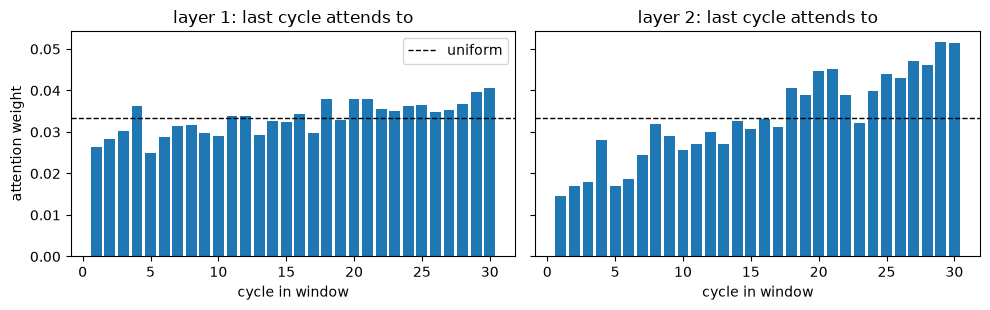

layer 1: mean entropy 99.8% of uniform, largest weight 0.041, last 5 cycles get 18.7% of the last row (uniform: 16.7%)
layer 2: mean entropy 98.5% of uniform, largest weight 0.056, last 5 cycles get 23.9% of the last row (uniform: 16.7%)
engine 3, true RUL 0


In [8]:
import matplotlib.pyplot as plt


@torch.no_grad()
def attention(model, window):
    model.eval()
    h = model.inp(torch.from_numpy(window.T[None].copy())) + model.pos
    maps = []
    for layer in model.enc.layers:
        z = layer.norm1(h)
        out, w = layer.self_attn(z, z, z, need_weights=True, average_attn_weights=True)
        maps.append(w[0].numpy())
        h = h + out
        h = h + layer._ff_block(layer.norm2(h))
    return maps


i = int(np.argmin(yte))                  # the scoring window closest to failure
maps = attention(models['transformer'], Xte[i])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for k, (ax, A) in enumerate(zip(axes, maps), start=1):
    ax.bar(np.arange(1, WINDOW + 1), A[-1], color='C0')
    ax.axhline(1 / WINDOW, color='k', ls='--', lw=1, label='uniform')
    ax.set_title(f'layer {k}: last cycle attends to')
    ax.set_xlabel('cycle in window')
axes[0].set_ylabel('attention weight')
axes[0].legend()
plt.tight_layout()
plt.show()

for k, A in enumerate(maps, start=1):
    p = np.clip(A, 1e-12, 1)
    entropy = float((-(p * np.log(p)).sum(1) / np.log(WINDOW)).mean())
    print(f'layer {k}: mean entropy {entropy:.1%} of uniform, largest weight {A.max():.3f}, '
          f'last 5 cycles get {A[-1, -5:].sum():.1%} of the last row (uniform: {5 / WINDOW:.1%})')
print(f'engine {gte[i]}, true RUL {yte[i]:.0f}')

The weights sit close to the uniform line, and entropy near 100% means close to uniform
across every row. A nearly uniform attention followed by a mean over cycles computes
something close to a window average, which is information boosting already gets as a
feature. Head-averaging can hide sharper individual heads, so this is a summary rather than
a proof, but it fits the RMSE: with about 70 training engines, the model that assumes the
least about order and locality has the least data to learn them from.

---

## Takeaway

We matched three architectures to the same sensor windows and gave them one training recipe
(schedule, early stopping, clipping, weight decay), with every epoch and the best checkpoint
in MLflow. The grouped split kept every engine on one side, and gradient boosting on four
summary features set the bar. On this small benchmark no network runs away with it, and the
transformer, which assumes the least, trails. The order test shows why the positional
encoding exists and how little this transformer leans on it. Assignment **A6** has you
build, train, and honestly evaluate a deep model against a real baseline, so it starts here.